# Checkpoint 6 : Feature Importance analysis


## 1. Restoring

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

pd.set_option("display.max_columns", 60)


In [57]:
df = pd.read_csv("cars.csv")

df

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.0,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.6,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.0,AZN,Şəmi,NaN,507687355.0,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.7,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.0,AZN,NaN,Lada Azərbaycan,554092445.0,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.0,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.0,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.0,USD,Anar,NaN,502126242.0,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.0,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.0,AZN,Babək,NaN,774999004.0,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-957a4c43c25d,/autos/8674773-toyo

In [58]:
# Remove duplicate listings
df = df.drop_duplicates(subset="id_x").copy()

In [59]:
# Build a single price column in AZN using fixed exchange rates
FX = {"AZN": 1.0, "$": 1.70, "€": 1.85}
df["price_azn"] = df["price_x"] * df["currency_x"].map(FX)
df = df[df["price_azn"].notnull()].copy()

In [60]:
feature_columns = [
    "production_year",
    "engine_displacement_num",
    "kilometrage_num",
    "views",
    "city",
    "Ban növü",
    "Marka",
    "Rəng",
    "Sahiblər",
    "Sürətlər qutusu",
    "Vəziyyəti",
    "Yerlərin sayı",
    "Ötürücü",
]
target_column = "price_azn"

In [61]:
df_model = df[feature_columns + [target_column]].copy()

In [62]:
X = df_model[feature_columns]
y = df_model[target_column]

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [64]:
numeric_features = ["production_year", "engine_displacement_num", "kilometrage_num", "views"]
categorical_features = ["city", "Ban növü", "Marka", "Rəng", "Sahiblər",
                         "Sürətlər qutusu", "Vəziyyəti", "Yerlərin sayı", "Ötürücü"]

In [65]:
numeric_pipeline = Pipeline(steps = [
    ("impute", SimpleImputer(strategy = "median")),
    ("scale", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy = "constant", fill_value = "Unknown")),
    ("encode", OneHotEncoder(handle_unknown="ignore")),
])


In [66]:
preprocessor = ColumnTransformer(transformers = [
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators = 100,
                                    max_depth = 10,
                                    random_state = 42,
                                    n_jobs = -1)),
])

In [67]:
random_forest_model.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


## 2. Pull out feature importances

One-hot encoding turns one categorical column into many columns (one per brand). So the raw importance list has one row per encoded column, not per original feature. To make this readable, importances are grouped back by their original column name and summed.


In [75]:
encoded_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()
importances = random_forest_model.named_steps["model"].feature_importances_

In [76]:
raw_importance_df = pd.DataFrame({
    "encoded_feature": encoded_names,
    "importance": importances,
})

In [77]:
# Recover the original column name
def original_column(name):
    name = name.split("__", 1)[1] if "__" in name else name
    for col in numeric_features + categorical_features:
        if name == col or name.startswith(col + "_"):
            return col
    return name

In [78]:
raw_importance_df["original_feature"] = raw_importance_df["encoded_feature"].apply(original_column)

In [79]:
grouped_importance_df = (
    raw_importance_df.groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending= False)
    .reset_index()
)
grouped_importance_df

,original_feature,importance
0,engine_displacement_num,0.438230
1,production_year,0.276965
2,kilometrage_num,0.074488
3,Ötürücü,0.070201
4,Marka,0.060766
5,Sürətlər qutusu,0.028547
6,Yerlərin sayı,0.023165
7,Ban növü,0.019971
8,Rəng,0.003444
9,Sahiblər,0.002349


## 3. Feature importance plot

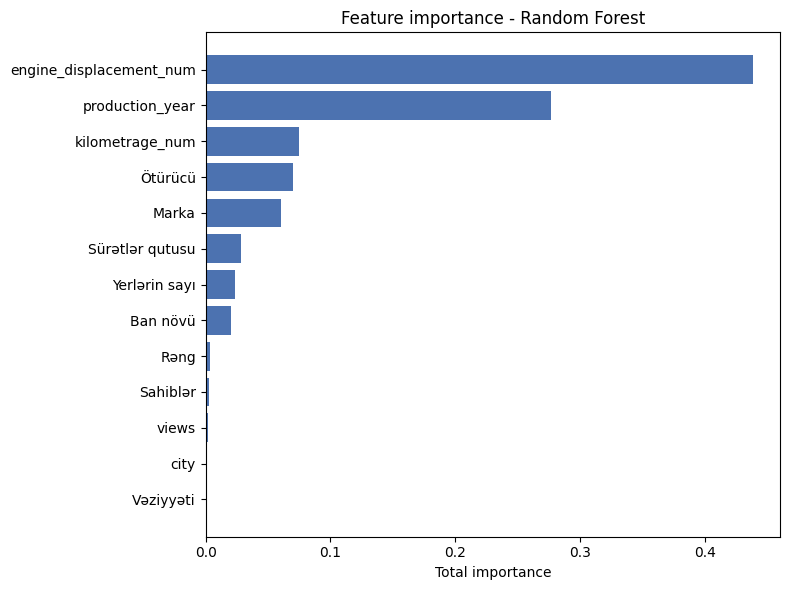

In [81]:
plt.figure(figsize = (8, 6))
plt.barh(grouped_importance_df["original_feature"], grouped_importance_df["importance"], color = "#4C72B0")
plt.gca().invert_yaxis()
plt.xlabel("Total importance")
plt.title("Feature importance - Random Forest")
plt.tight_layout()
plt.show()


## 4. Written interpretation

The feature importance plot shows that engine displacement, production year, and drivetrain are the most influential predictors of car price.

Engine size came out as the strongest signal, since it closely tracks a car's class and price segment, followed by production year, since newer cars are worth more.

Drivetrain type ranked third, likely because it also correlates with vehicle segment, like SUVs tending to be pricier.

Mileage and brand still matter, but less than expected, probably because engine size and year already capture much of that signal.

Features like color, views, owner count, city, and condition barely matter, each under 1% of the total.

Overall, the model's accuracy mainly depends on engine size, production year, drivetrain, mileage, and brand being clean and complete, so the low-importance features could be dropped without much impact.

## Finally

The Random Forest model identified the most influential predictors of car price by aggregating feature importances back to the original feature names after one-hot encoding.

Engine displacement, production year, and drivetrain contributed the most to the model's predictions, while variables such as color and city had relatively little impact.

Combined with the previous stages - data preprocessing, model training, evaluation, and cross-validation—this completes a full end-to-end regression workflow.
